In [144]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [145]:
folder = '/content/drive/MyDrive/TransformesCod/05-Service_Center/'
file_path = '/content/drive/MyDrive/TransformesCod/05-Service_Center/photos/fer2013.csv'

import pandas as pd
df = pd.read_csv(file_path)
df.head()

,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


In [146]:
import numpy as np
def process_pixels(string_pixels):
  lst = list(map(int, string_pixels.split()))
  pixels = np.array(lst , dtype=np.uint8)
  return pixels

df['pixels_array'] = df['pixels'].apply(process_pixels)
df.head(1)

,emotion,pixels,Usage,pixels_array
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training,"[70, 80, 82, 72, 58, 58, 60, 63, 54, 58, 60, 4..."


In [147]:
df_training = df[df['Usage'] == 'Training']
emo_count = df_training['emotion'].value_counts()
min_emo_training_counts = emo_count.min()
min_emo_training_counts

436

In [148]:
df_PublicTest = df[df['Usage'] == 'PublicTest']
emo_count = df_PublicTest['emotion'].value_counts()
min_emo_PublicTest_counts = emo_count.min()
min_emo_PublicTest_counts

56

In [149]:
df_PrivateTest = df[df['Usage'] == 'PrivateTest']
emo_count = df_PrivateTest['emotion'].value_counts()
min_emo_PrivateTest_counts = emo_count.min()
min_emo_PrivateTest_counts

55

In [150]:
emo = df['emotion'].unique()
selected_emo = []
for e in emo:
  emo_rows = df[(df['emotion'] == e) & (df['Usage'] == 'Training')]
  random_i = np.random.choice(emo_rows.index , size=2*min_emo_training_counts , replace=True)
  selected_emo.extend(random_i)
fer_training_df = df.loc[selected_emo]
fer_training_df.reset_index(drop=True , inplace=True)
fer_training_df.head(1)

,emotion,pixels,Usage,pixels_array
0,0,51 16 8 39 115 131 118 106 108 114 128 138 126...,Training,"[51, 16, 8, 39, 115, 131, 118, 106, 108, 114, ..."


In [151]:
emo = df['emotion'].unique()
selected_emo = []
for e in emo:
  emo_rows = df[(df['emotion'] == e) & (df['Usage'] == 'PublicTest')]
  random_i = np.random.choice(emo_rows.index , size=2*min_emo_PublicTest_counts , replace=True)
  selected_emo.extend(random_i)
fer_PublicTest_df = df.loc[selected_emo]
fer_PublicTest_df.reset_index(drop=True , inplace=True)
fer_PublicTest_df.head(1)

,emotion,pixels,Usage,pixels_array
0,0,15 15 15 15 16 17 18 21 40 106 167 201 119 21 ...,PublicTest,"[15, 15, 15, 15, 16, 17, 18, 21, 40, 106, 167,..."


In [152]:
emo = df['emotion'].unique()
selected_emo = []
for e in emo:
  emo_rows = df[(df['emotion'] == e) & (df['Usage'] == 'PrivateTest')]
  random_i = np.random.choice(emo_rows.index , size=2*min_emo_PrivateTest_counts , replace=True)
  selected_emo.extend(random_i)
fer_PrivateTest_df = df.loc[selected_emo]
fer_PrivateTest_df.reset_index(drop=True , inplace=True)
fer_PrivateTest_df.head(1)

,emotion,pixels,Usage,pixels_array
0,0,109 110 118 109 63 59 55 58 52 31 29 28 27 37 ...,PrivateTest,"[109, 110, 118, 109, 63, 59, 55, 58, 52, 31, 2..."


In [153]:
print(len(fer_training_df))
print(len(fer_PublicTest_df))
print(len(fer_PrivateTest_df))

6104
784
770


In [154]:
pixel_array = fer_training_df.loc[0 , 'pixels_array']
pixel_array

array([51, 16,  8, ..., 52, 49, 42], dtype=uint8)

array([[ 51,  16,   8, ...,   0,   0,   0],
       [ 66,  20,   3, ...,   0,   0,   0],
       [ 73,  20,  12, ...,   0,   0,   0],
       ...,
       [162, 218, 202, ...,  72,  56,  43],
       [216, 195, 179, ...,  61,  49,  42],
       [181, 179, 179, ...,  52,  49,  42]], dtype=uint8)
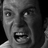

In [155]:
img0 = np.reshape(pixel_array , (48 , 48))
img0

In [156]:
img0_rgb = img0[... , np.newaxis]
img0_rgb.shape

(48, 48, 1)

In [157]:
img0_rgb = np.repeat(img0_rgb , 3 , axis=-1)
img0_rgb.shape

(48, 48, 3)

In [158]:
def prepare_fer_data(df):
  img_lst = []
  img_labels = list(map(int , df['emotion']))
  for i , row in df.iterrows():
    pixel_array = row['pixels_array']
    img = np.reshape(pixel_array , (48 , 48))
    img_rgb = img[... , np.newaxis]
    img_rgb = np.repeat(img_rgb , 3 , axis=-1)
    img_rgb = img_rgb.astype(int).tolist()
    img_lst.append(img_rgb)
  output_df = pd.DataFrame(list(zip(img_lst , img_labels)), columns= ['img' , 'labels'])
  return output_df


In [159]:
fer_training_df = prepare_fer_data(fer_training_df)
fer_PublicTest_df = prepare_fer_data(fer_PublicTest_df)
fer_PrivateTest_df = prepare_fer_data(fer_PrivateTest_df)

In [161]:
fer_training_df.head(1)

,img,labels
0,"[[[51, 51, 51], [16, 16, 16], [8, 8, 8], [39, ...",0


In [162]:
!pip install datasets

In [164]:
from datasets import *
training_dataset = Dataset.from_pandas(fer_training_df)
training_dataset

Dataset({
    features: ['img', 'labels'],
    num_rows: 6104
})

In [165]:
PublicTest_dataset = Dataset.from_pandas(fer_PublicTest_df)
PrivateTest_dataset = Dataset.from_pandas(fer_PrivateTest_df)

In [166]:
training_dataset.save_to_disk(folder + 'training_dataset')
PublicTest_dataset.save_to_disk(folder + 'PublicTest_dataset')
PrivateTest_dataset.save_to_disk(folder + 'PrivateTest_dataset')

Saving the dataset (0/1 shards):   0%|          | 0/6104 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/784 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/770 [00:00<?, ? examples/s]